In [26]:
from adabmDCA import import_from_fasta
import pandas as pd

seed = 1
out_dir = "../experiments/datasets/RR/t10.4_t20.7_repeated/"
out_prefix=f"{out_dir}source"
in_fasta="../experiments/datasets/RR/RR.fasta"
test_name=f"{out_prefix}.test.fasta"
train_name=f"{out_prefix}.train.fasta"

csv_file_source = "../experiments/datasets/RR/RR.csv"

df_source = pd.read_csv(csv_file_source)
h_train, _ = import_from_fasta(train_name)
h_test, _ = import_from_fasta(test_name)

In [29]:
df_train = df_source[df_source['header'].isin(h_train)]
df_test = df_source[df_source['header'].isin(h_test)]
# estract 2000 random samples from train set. It has to be balanced on the labels.
num_classes = df_train['label'].nunique()
df_train_now = df_train.copy()
for num_extract in [2000, 1000, 500, 100]:
    num_extract_per_class = num_extract // num_classes
    df_train_sampled = df_train_now.groupby('label', group_keys=False).apply(lambda x: x.sample(n=num_extract_per_class, random_state=seed))
    df_train_sampled = df_train_sampled.sample(frac=1, random_state=seed).reset_index(drop=True)  # Shuffle
    df_train_sampled.to_csv(f"{out_dir}seed_{seed}.train_{num_extract}.csv", index=False)
    print(f"Saved {out_dir}seed_{seed}.train_{num_extract}.csv")
    print(f"length of train set: {len(df_train_sampled)}")
    df_train_now = df_train_sampled

Saved ../experiments/datasets/RR/t10.4_t20.7_repeated/seed_1.train_2000.csv
length of train set: 2000
Saved ../experiments/datasets/RR/t10.4_t20.7_repeated/seed_1.train_1000.csv
length of train set: 1000
Saved ../experiments/datasets/RR/t10.4_t20.7_repeated/seed_1.train_500.csv
length of train set: 496
Saved ../experiments/datasets/RR/t10.4_t20.7_repeated/seed_1.train_100.csv
length of train set: 96


/tmp/ipykernel_1254921/3989526679.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_sampled = df_train_now.groupby('label', group_keys=False).apply(lambda x: x.sample(n=num_extract_per_class, random_state=seed))
/tmp/ipykernel_1254921/3989526679.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_sampled = df_train_now.groupby('label', group_keys=False).apply(lambda x: x.sample(n=num_extract_per_c

<Axes: xlabel='label', ylabel='count'>

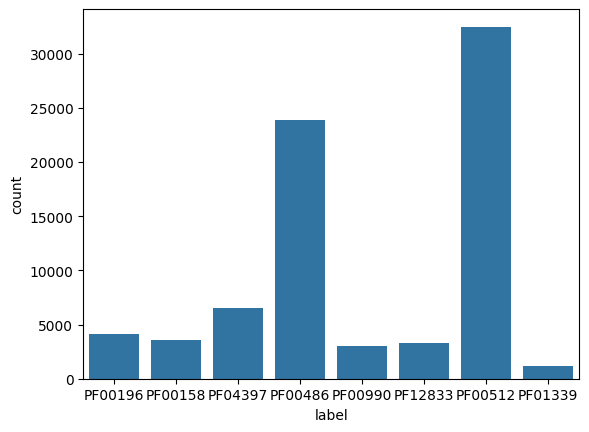

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df_train)

<Axes: xlabel='label', ylabel='count'>

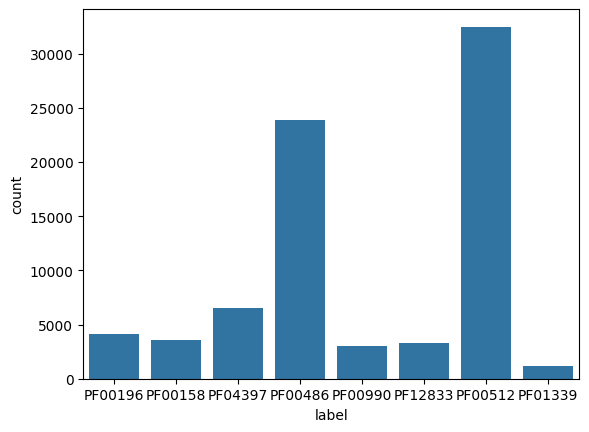

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df_test)

In [28]:
print(len(df_train), len(df_test))

12700 78053
